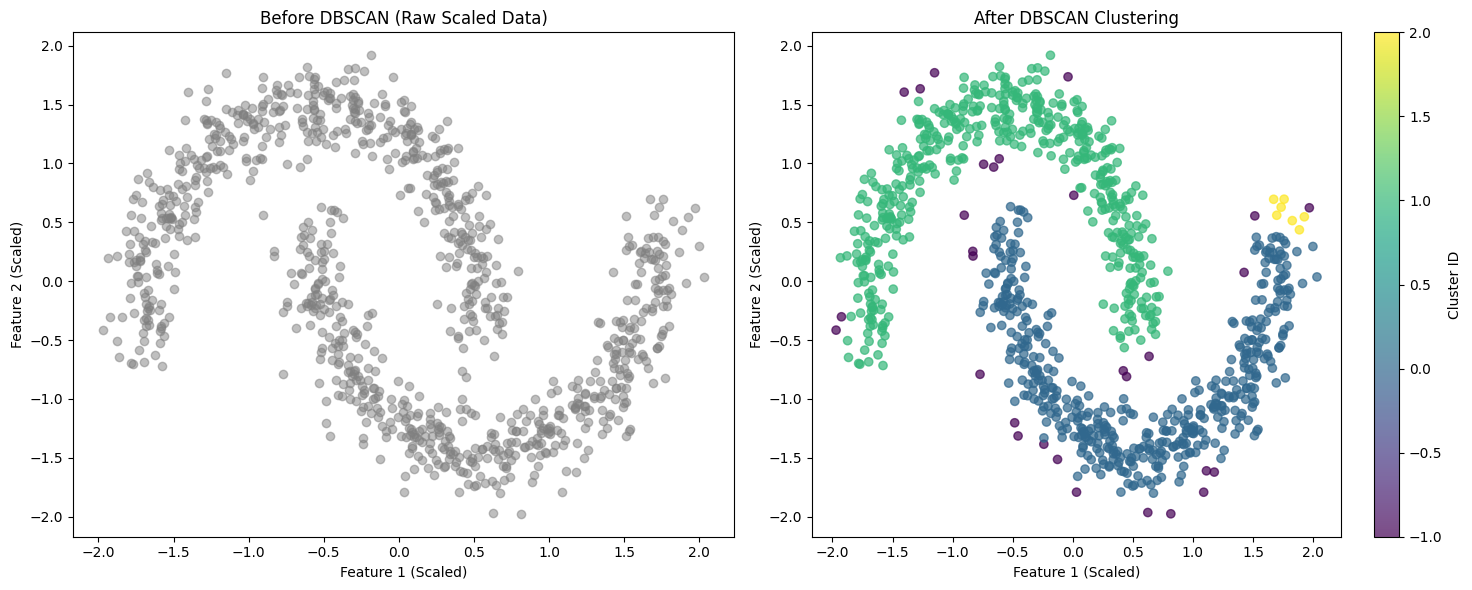

মোট নয়েজ পয়েন্ট সংখ্যা: 30
শনাক্তকৃত ক্লাস্টার আইডি সমূহ: [-1  0  1  2]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ১. ডেটাসেট তৈরি
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# ২. ফিচার স্কেলিং (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ৩. DBSCAN মডেল তৈরি
# এখানে eps 0.15 করা হয়েছে যাতে আলাদা আলাদা গ্রুপ বোঝা যায়
dbscan = DBSCAN(eps=0.15, min_samples=5)           # >>>>>>  0.3, 0.2 ইত্যাদি মান নেয়ার পর মনে হলো 0.15 মানটাই সেরা। >>>>>

# eps=0.15: এটি হচ্ছে একটি বিন্দুর চারপাশের 'রেডিয়াস' বা ব্যাসার্ধ।
# একটি বিন্দু থেকে 0.15 দূরত্বের মধ্যে অন্য কোনো বিন্দু থাকলে তাকে প্রতিবেশী ধরা হবে।

# min_samples=5: একটি বিন্দুকে 'কোর পয়েন্ট' (Core Point) হতে হলে তার চারপাশের
# ওই 0.15 ব্যাসার্ধের মধ্যে নিজেকেসহ নূন্যতম ৫টি ডাটা পয়েন্ট থাকতে হবে।

# ৪. ফিট এবং প্রেডিক্ট
clusters = dbscan.fit_predict(X_scaled)

# এটি একই সাথে দুটি কাজ করে:
# - মডেলটিকে ডেটার ওপর Fit করে (অর্থাৎ ক্লাস্টারগুলো খুঁজে বের করে)।
# - সাথে সাথে প্রতিটি ডেটা পয়েন্ট কোন ক্লাস্টারে পড়েছে সেই Labels গুলো রিটার্ন করে।

# dbscan.fit(X_scaled) শুধু মডেলটিকে ট্রেইন বা Fit করে। এটি সরাসরি কোনো লেবেল রিটার্ন করে না। লেবেলগুলো দেখতে হলে
# আলাদাভাবে labels_ অ্যাট্রিবিউট কল করতে হয়।

# ৫. ভিজ্যুয়ালাইজেশন (DBSCAN এর আগে এবং পরে)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# DBSCAN এর আগে: শুধু স্কেল করা ডাটা (কোনো ক্লাস্টার নেই)
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', alpha=0.5)
ax1.set_title("Before DBSCAN (Raw Scaled Data)")
ax1.set_xlabel("Feature 1 (Scaled)")
ax1.set_ylabel("Feature 2 (Scaled)")

# DBSCAN এর পরে: ক্লাস্টার অনুযায়ী কালারড ডাটা
# cmap 'viridis' বা 'tab10' ব্যবহার করলে রঙগুলো আলাদা বোঝা যায়
scatter = ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', alpha=0.7)
ax2.set_title("After DBSCAN Clustering")
ax2.set_xlabel("Feature 1 (Scaled)")
ax2.set_ylabel("Feature 2 (Scaled)")
plt.colorbar(scatter, ax=ax2, label='Cluster ID')

plt.tight_layout()
plt.show()

# নয়েজ পয়েন্টের সংখ্যা দেখা
n_noise = list(clusters).count(-1)
print(f"মোট নয়েজ পয়েন্ট সংখ্যা: {n_noise}")
print(f"শনাক্তকৃত ক্লাস্টার আইডি সমূহ: {np.unique(clusters)}")